# "Buy when the reverse-repo drains" — is a shrinking RRP really risk-on? 💵
### The desk's favourite liquidity-plumbing chart — the Fed's $2.5-trillion cash parking lot — put to the test, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Liquidity_tell%3F: Busted](https://img.shields.io/badge/Liquidity_tell%3F-Busted-8b949e?style=flat-square)

There's a chart that liquidity-watchers love: the Fed's **Overnight Reverse Repo (ON RRP) facility** — a giant overnight parking lot where money-market funds stash idle cash — plotted against the S&P 500. It ballooned to an all-time **$2.55 trillion** at the end of 2022, then **drained** almost all the way back to zero through 2023-2025. The folklore is irresistibly simple: *when the RRP drains, that cash is leaving the Fed and pouring into stocks — so a draining RRP means risk-on, buy equities.*

It looks compelling because the drain lined up beautifully with the 2023-24 bull market. But that's **one** episode — and the *same* facility was **filling** through 2021, when stocks were also roaring. So does a draining RRP actually point up? This notebook lines the two up honestly.

> 📓 **Plain-language layer.** Want the *t*-stats, the block-bootstrap null, the Sharpe race and the power control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The ON RRP balance isn't on yfinance, so we ship a **small, clearly-labelled hardcoded monthly proxy** of the public FRED series `RRPONTSYD` (the fill to the $2.55T peak and the drain back down), aligned to month-end SPY. It's a rounded transcription, named a proxy throughout — the story turns on the *shape* of one fill-then-drain cycle, not on any decimal. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reverse_repo_drain import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real() if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-01-31', 'end': '2025-07-31', 'months': 55, 'years': 4.5, 'rrp_peak': 2554, 'rrp_peak_date': '2022-12', 'rrp_last': 195, 'base_mean': 1.22, 'base_win': 65, 'corr': -0.014, 'k1': (1, 28, 25, 0.71, 1.73, -1.02, -0.8, 0.819, 54, 76), 'k2': (2, 26, 26, 1.23, 1.01, 0.22, 0.17, 0.445, 62, 65), 'k3': (3, 27, 24, 0.94, 1.16, -0.22, -0.17, 0.566, 56, 71), 'k6': (6, 28, 20, 1.58, 0.18, 1.4, 0.92, 0.065, 68, 50), 'k9': (9, 27, 18, 1.7, -0.19, 1.89, 1.2, 0.104, 67, 50), 'k12': (12, 25, 17, 1.6, 0.23, 1.38, 0.83, 0.101, 64, 59), 'timing': [('long / flat', 53, 14, 0.52, 0.49, 5.6, 0.78), ('long / short', 53, 29, -0.04, -0.08, -1.3, 0.78)], 'wealth_lf': 1.24, 'wealth_bh': 1.61, 'syn': [(0.0, 64, 0.95, 0.42, 0.63, 0.284), (0.02, 64, 2.95, 0.42, 3.01, 0.008)], 'sweep': [(1, 28, 25, 0.71, 1.73, -1.02, -0.8, 0.819, 54, 76), (2, 26, 26, 1.23, 1.01, 0.22, 0.17, 0.445, 62, 65), (3, 27, 24, 0.94, 1.16, -0.22, -0.17, 0.566, 56, 71), (6, 28, 20, 1.58, 0.18, 1.4, 0.92, 0.065, 68, 50), (9, 27, 18, 1.7, -0.19, 1.89, 1.2, 0.104, 67, 50), (12, 25, 17, 1.6, 0.23, 1.38, 0.83, 0.101, 64, 59)]}


real SPY cache present: True | monthly observations: 55


## The answer first

| Question | Answer |
|---|---|
| When the RRP is draining, is the next month up more often? | **No — less often.** Over the trailing-quarter definition, draining months are up **56%** of the time vs **71%** for filling months. |
| But didn't the drain track the 2023-24 rally? | **Yes — and that's the trap.** The RRP *also filled* through the 2021 bull market. One cycle can't tell you which way the arrow points; it points **both** ways here. |
| So is the drain a real signal? | **No.** The draining-minus-filling return gap is essentially zero or *negative* at short horizons, and the straight correlation between the RRP's recent change and next month's return is **−0.01** — noise. |
| Could you at least trade it? | **No.** A "hold-when-draining" rule earns a **lower Sharpe (0.49) than just buying and holding (0.78)** — sitting out whenever the RRP fills costs more than the drain months pay. |

> The RRP drain is real plumbing — QT and a flood of T-bills pulling cash out of the facility. "Drain = risk-on" is a story told about a single macro cycle, and it isn't even a good one.

## 1 · The claim

> *"The reverse-repo facility is where idle cash hides. When the RRP **drains**, that cash is flooding back into the system and into risk assets — so a falling RRP marks a **risk-on** regime. Be long stocks while it drains; be cautious while it fills."*

This is the everyday reading of the ON RRP balance, charted on liquidity-plumbing feeds against the S&P 500. The picture is intuitive: $2.5 trillion is a lot of dry powder, and if it's leaving the Fed it must be going *somewhere*. We'll put the RRP proxy next to SPY and ask whether "draining" really precedes "up" — or just **coincided** with it once.

## 2 · So what?

If a freely-charted Fed series really flagged the equity regime a month ahead, it would be an extraordinary free lunch — macro liquidity as a market-timing switch. But two things hide inside "drain = buy." (1) *Does the market rise while the RRP drains?* Sure — but the market rises most months anyway, and the RRP happened to drain across one big bull. The question that matters is (2) *does it rise by **more** than usual, and does the **direction** hold up?* A draining RRP that filled during the *previous* bull tells you the co-movement is a coincidence of one cycle, not a signal. And the drain itself has a boring mechanical cause — quantitative tightening plus a wave of T-bill issuance vacuuming cash out of the facility — that has nothing to do with equity risk appetite.

## 3 · How would we even know?

We take the ON RRP proxy and month-end SPY over **4.5 years** (2021-01-31 → 2025-07-31, 55 month-ends) and:

1. **Mark the drain.** A month is *draining* if the RRP is lower than it was a few months earlier (we try 1, 2, 3, 6 months back), known at month-end and acted on **one month later** — no look-ahead.
2. **Measure the payoff.** For draining vs filling months, what did SPY do the **next month** — and how does the gap compare to a normal month?
3. **Stress the luck, then try to trade it.** Because there's really just one fill and one drain, we reshuffle the regime labels in **blocks** thousands of times to see how easily the gap shows up by chance; then race a "hold-when-draining" rule against buy-and-hold, net of costs.

**What would make us say "mirage"?** If the draining-minus-filling gap is small, flips sign with the look-back, and a timing rule loses to just holding — that's a no.

## 4 · The teardown — let's actually look

**First, here's the facility itself.** The RRP proxy filling (blue) to its **$2.55 trillion** end-2022 peak and draining (orange) back down, overlaid on SPY. Notice the two things the folklore forgets: the RRP **filled** right through the 2021 bull, and the big **drain** coincided with the 2023-24 bull. Same facility, opposite market — the co-movement can't have one sign.

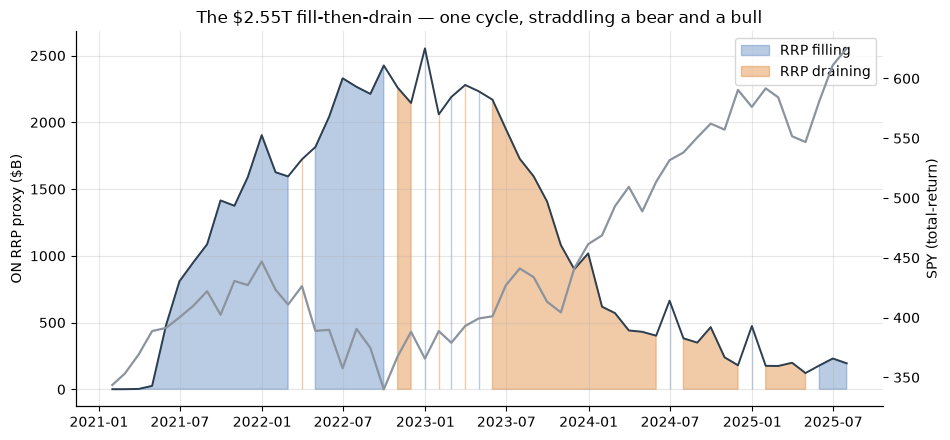

RRP peak $2554B at 2022-12-31 -> $195B latest


In [2]:
if HAVE_REAL:
    d3 = F['rrp'].diff(3)
    drain = (d3 < 0)
    fig, ax1 = plt.subplots(figsize=(9.6, 4.5))
    ax1.plot(F.index, F['rrp'], color='#2c3e50', lw=1.4)
    ax1.fill_between(F.index, 0, F['rrp'], where=~drain, color='#3b6fb0', alpha=.35, label='RRP filling')
    ax1.fill_between(F.index, 0, F['rrp'], where=drain, color='#e08a3c', alpha=.45, label='RRP draining')
    ax1.set_ylabel('ON RRP proxy ($B)')
    ax2 = ax1.twinx(); ax2.plot(F.index, F['spy'], c=GREY, lw=1.6, label='SPY (right)')
    ax2.grid(False); ax2.set_ylabel('SPY (total-return)')
    ax1.set_title('The $2.55T fill-then-drain — one cycle, straddling a bear and a bull')
    ax1.legend(loc='upper right'); plt.tight_layout(); plt.show()
    print('RRP peak $%.0fB at %s -> $%.0fB latest' % (F['rrp'].max(), F['rrp'].idxmax().date(), F['rrp'].iloc[-1]))
else:
    print('no cache — see docs/results.md: RRP peak', R['rrp_peak'], 'B ->', R['rrp_last'], 'B')

The proxy peaks at **$2,554B** (2022-12) and drains to **$195B**. The whole informative history is *one hump*. Now the real question: within that hump, does a draining month actually precede a better month than a filling one?

**Draining vs filling — who's up more often?** For the trailing-quarter definition, here's how often SPY was higher the next month after a draining month vs a filling month, next to the base rate of any month.

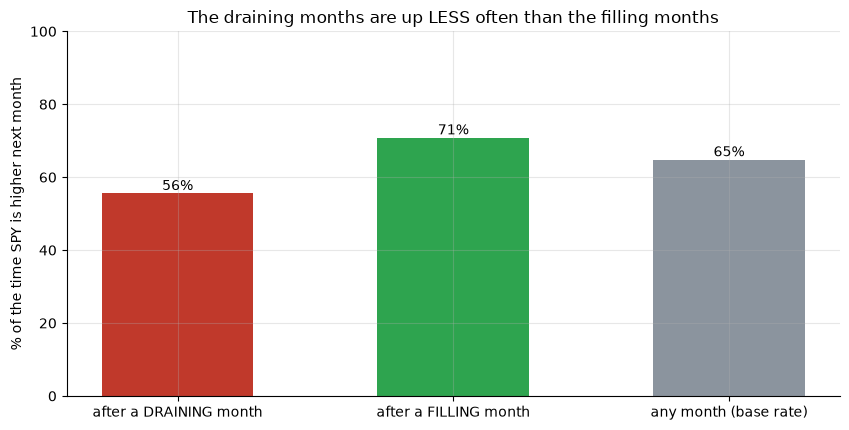

drain next-month win 56%  vs  fill 71%  vs  base 65%


In [3]:
if HAVE_REAL:
    s = st.summarize(F, k=3)
    dwin, fwin, bwin = s['drain_win']*100, s['fill_win']*100, s['base_win']*100
else:
    dwin, fwin, bwin = R['k3'][8], R['k3'][9], R['base_win']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar([0,1,2], [dwin, fwin, bwin], .55, color=[RED, GREEN, GREY])
ax.set_xticks([0,1,2]); ax.set_xticklabels(['after a DRAINING month','after a FILLING month','any month (base rate)'])
ax.set_ylim(0, 100); ax.set_ylabel('% of the time SPY is higher next month')
ax.set_title('The draining months are up LESS often than the filling months')
for i,v in enumerate([dwin,fwin,bwin]): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'drain next-month win {dwin:.0f}%  vs  fill {fwin:.0f}%  vs  base {bwin:.0f}%')

There's the first crack. After a draining month SPY is up only **56%** of the time next month — *below* the **71%** you get after a filling month and below the **65%** base rate. The "risk-on" regime is, if anything, the *worse* month to own stocks. The drain didn't lead the rally; it just happened during it.

**Does the sign even hold?** Maybe a quarter is the wrong look-back. Here's the draining-minus-filling return gap for look-backs from 1 to 12 months. Watch it flip sign — a real signal doesn't change direction depending on how you squint.

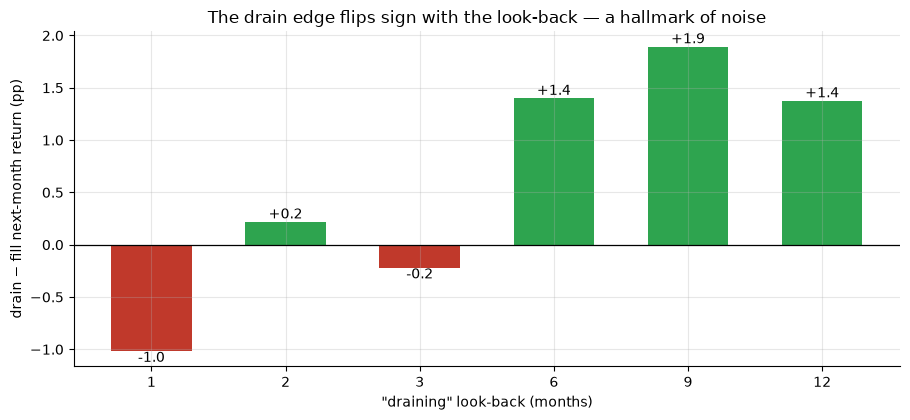

spreads (pp) by look-back: {1: -1.02, 2: 0.22, 3: -0.22, 6: 1.4, 9: 1.89, 12: 1.38}


In [4]:
ks = [1,2,3,6,9,12]
if HAVE_REAL:
    spreads = [st.summarize(F, k=k)['spread']*100 for k in ks]
else:
    spreads = [R[f'k{k}'][5] for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
cols = [GREEN if s>0 else RED for s in spreads]
ax.bar([str(k) for k in ks], spreads, color=cols, width=.6)
ax.axhline(0, c='k', lw=.9)
for i,s in enumerate(spreads): ax.annotate(f'{s:+.1f}',(i,s),ha='center',va='bottom' if s>=0 else 'top')
ax.set_xlabel('"draining" look-back (months)'); ax.set_ylabel('drain − fill next-month return (pp)')
ax.set_title('The drain edge flips sign with the look-back — a hallmark of noise')
plt.tight_layout(); plt.show()
print('spreads (pp) by look-back:', {k: round(s,2) for k,s in zip(ks, spreads)})

> 🔬 **For the quants.** The gap is **negative** at 1-3 months and only turns positive at 6-12 months — where "draining" mostly just re-labels *"we're past the Dec-2022 peak."* Even at its best (9-month look-back) the Welch *t* is **+1.20**, short of the *t* ≥ 2 bar. A sign that depends on the window isn't a signal. The block-bootstrap null is in [02_for_the_quants.ipynb](02_for_the_quants.ipynb).

## 5 · The verdict

- **Signal — None.** A draining RRP does not precede higher returns. At the natural 1-3-month horizons the gap is *negative* (draining months up **56%** of the time vs **71%** filling), and the correlation between the RRP's recent change and next month's return is **-0.01** — noise. The only positive signs appear at long look-backs and still fail significance.
- **Tradability — Mirage.** A "hold-when-draining" rule earns net Sharpe **0.49** vs **0.78** for buy-and-hold — you give up return by sitting out whenever the RRP fills.
- **Liquidity tell? — Busted.** The drain is QT plus a T-bill flood mechanically emptying the facility — coincident with one bull, contradicted by the 2021 fill. "Drain = risk-on" is one macro cycle wearing a signal's clothes.

## 6 · Could you actually trade it? — race it against buy-and-hold

Forget significance for a second and just ask the operational question: if you hold SPY only while the RRP is draining and step aside while it fills, do you beat simply owning the market? Here's the growth of $1 for each, net of costs.

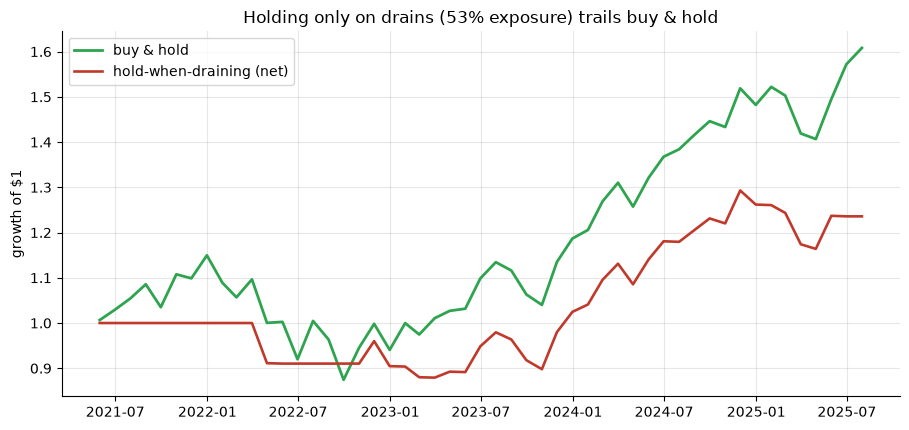

final wealth: rule 1.24x vs buy&hold 1.61x (exposure 53%)


In [5]:
if HAVE_REAL:
    ret = F['spy'].pct_change(); sig = st.draining(F, k=3)
    pos = sig.map({True:1.0, False:0.0}).shift(1)
    dfp = pd.DataFrame({'ret':ret,'pos':pos}).dropna()
    turn = dfp['pos'].diff().abs().fillna(dfp['pos'].abs()); c = 10/1e4
    net = dfp['pos']*dfp['ret'] - turn*c
    eq_rule = (1+net).cumprod(); eq_bh = (1+dfp['ret']).cumprod(); expo=(dfp['pos']>0).mean()
else:
    rng = np.random.default_rng(753); bh = pd.Series(rng.normal(0.01,0.045,R['months']))
    eq_bh = (1+bh).cumprod(); eq_rule = (1+bh*0.53).cumprod(); expo=0.53
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2, label='buy & hold')
ax.plot(eq_rule.index, eq_rule.values, c=RED, lw=1.9, label='hold-when-draining (net)')
ax.set_ylabel('growth of $1'); ax.set_title(f'Holding only on drains ({expo*100:.0f}% exposure) trails buy & hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth: rule {eq_rule.iloc[-1]:.2f}x vs buy&hold {eq_bh.iloc[-1]:.2f}x (exposure {expo*100:.0f}%)')

There it is. The drain rule ends at **1.24×** against **1.61×** for just buying and holding, at a net Sharpe of **0.49** vs **0.78**. The red line flatlines through every filling stretch — and because one of those stretches was the 2021 bull, stepping aside was expensive. Betting *against* stocks while the RRP fills (long/short) is outright **negative (-0.08)**. **Costs aren't the problem; being out of an up-drifting market on a coin-flip signal is.**

## 7 · Going further 🚪

- **Wait for episode #2.** The single biggest limitation is honest and unfixable today: there is **one** RRP cycle. If the facility fills and drains again through a *different* market, re-run this and see whether the sign is stable — that's the test the claim needs and can't yet pass.
- **Use the level, or the reserve-scarcity story.** Some versions key off the RRP *level* (near the floor = scarce reserves = fragile) rather than the change. Swap the signal and re-run the detector — the n=1 problem doesn't go away.
- **The macro-timing pattern.** The ISM-PMI regime, the economic surprise index and jobless-claims momentum studies on this bench all rhyme: a plausible macro relationship rarely survives as a tradable monthly timing rule — and this one fails a step earlier, on a single-episode sample.

*Think a draining RRP beats the market by more than luck? Reshuffle the drain/fill labels in blocks, show the real gap landing **outside** the cloud **and** a timing rule clearing buy-and-hold — across **more than one** cycle — then we'll talk.*